# 🏋️ Workout Efficacy Prediction


## 1. Imports

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid')

## 2. Load Clean Dataset

In [27]:
df = pd.read_csv('df_clean.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (12216, 54)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,meal_name,meal_type,diet_type,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle,Workout,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
0,52.31,Male,70.57,1.69,164.81,134.90,65.03,1.35,1336.50,Strength,25.103023,2.20,2.97,1.00,24.71,3.0,-0.02,242.70,83.61,55.52,1868.0,Other,Snack,Paleo,39.89,1002.62,159.76,226.34,Steamed,60.23,78.24,4.00,Leg Press,4.02,15.96,Builds explosive power,336.67,"Triceps, Chest",Step or Box,Intermediate,Abs,Grip Strength,Barbell curls,24.708519,1670.48,0.500670,1.184781,0.700241,0.818518,531.50,52.854797,909.0090,6.298462e+19,Low
1,45.10,Female,89.14,1.81,178.21,153.49,70.05,1.71,1335.85,Yoga,27.174402,3.52,4.99,3.02,27.21,3.0,0.00,283.05,113.03,75.74,2659.0,Other,Lunch,Vegetarian,21.15,204.90,120.85,456.97,Grilled,29.84,37.76,3.14,Burpees,4.00,19.89,Advanced core exercise,357.11,"Glutes, Hamstrings",Wall,Advanced,Forearms,Wrist Flexors,Hanging leg raises,27.209182,2265.98,0.499651,1.268005,0.771450,0.861287,1323.15,51.329688,1221.3162,1.019339e+20,High
2,49.02,Male,45.71,1.71,168.70,120.60,72.10,1.40,1008.00,Yoga,19.932593,2.61,3.97,2.00,15.63,3.0,-0.02,282.42,97.05,75.95,1917.0,Other,Snack,Paleo,3.04,862.64,171.00,299.88,Grilled,9.14,29.99,4.12,Jumping Jacks,5.00,25.06,Improves lower back strength,356.16,"Quadriceps, Glutes",Cable Machine or Resistance Band,Advanced,Forearms,Middle,Seated calf raises,15.632160,2269.31,0.497808,2.494421,0.502070,0.714878,227.00,36.598812,866.7620,9.973981e+19,Low


## 3. Define Target & Features

`Burns_Calories_Bin` is a pre-engineered column already in the dataset (Low / Medium / High).  
We use physiological and workout columns as features.

Target distribution:
Burns_Calories_Bin
Low          4004
High         2958
Medium       2901
Very High    2353
Name: count, dtype: int64


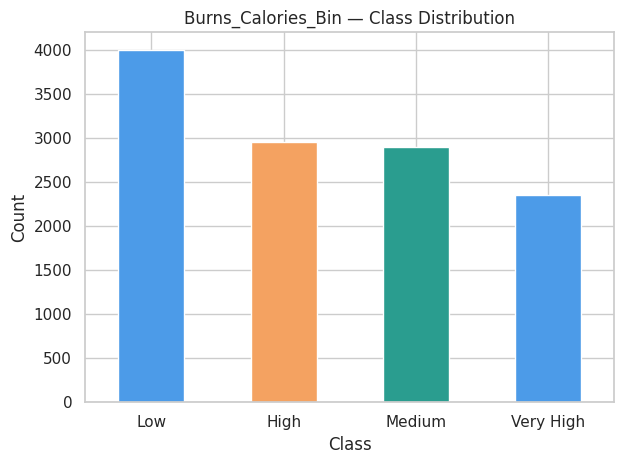

In [28]:
target = 'Burns_Calories_Bin'

print('Target distribution:')
print(df[target].value_counts())

df[target].value_counts().plot(kind='bar', color=['#4C9BE8','#F4A261','#2A9D8F'])
plt.title('Burns_Calories_Bin — Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
feature_cols = [
    'Age', 'Gender', 'Weight (kg)', 'Height (m)',
    'Max_BPM', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'Workout_Type',
    'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'
]

df_uc6 = df[feature_cols + [target]].copy()
print(f'Working dataset shape: {df_uc6.shape}')

Working dataset shape: (12216, 15)


## 4. Preprocessing
### 4.1 Encode categorical columns

In [30]:
le = LabelEncoder()

for col in ['Gender', 'Workout_Type']:
    df_uc6[col] = le.fit_transform(df_uc6[col].astype(str))

# Encode target
le_target = LabelEncoder()
df_uc6[target] = le_target.fit_transform(df_uc6[target].astype(str))
print('Target classes:', list(le_target.classes_))

Target classes: ['High', 'Low', 'Medium', 'Very High']


### 4.2 Split features and target

In [31]:
X = df_uc6.drop(target, axis=1)
y = df_uc6[target]

print('Missing values in X:', X.isnull().sum().sum())

Missing values in X: 0


### 4.3 Feature scaling

In [32]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

### 4.4 Train / Test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 9772 | Test: 2444


## 5. Train all 5 models

In [34]:
models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=5),
    'SVM':               SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'✅ {name} trained')

✅ Decision Tree trained
✅ Random Forest trained
✅ KNN trained
✅ SVM trained
✅ Logistic Regression trained


## 6. Evaluation

In [35]:
results = []

for name, model in trained.items():
    y_pred = model.predict(X_test)
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, average='weighted') * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted') * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred, average='weighted') * 100, 2),
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,85.11,85.15,85.11,84.92
2,KNN,72.30,72.53,72.30,72.25
0,Decision Tree,70.34,70.42,70.34,70.36
3,SVM,57.90,59.02,57.90,57.77
4,Logistic Regression,36.37,35.86,36.37,33.04


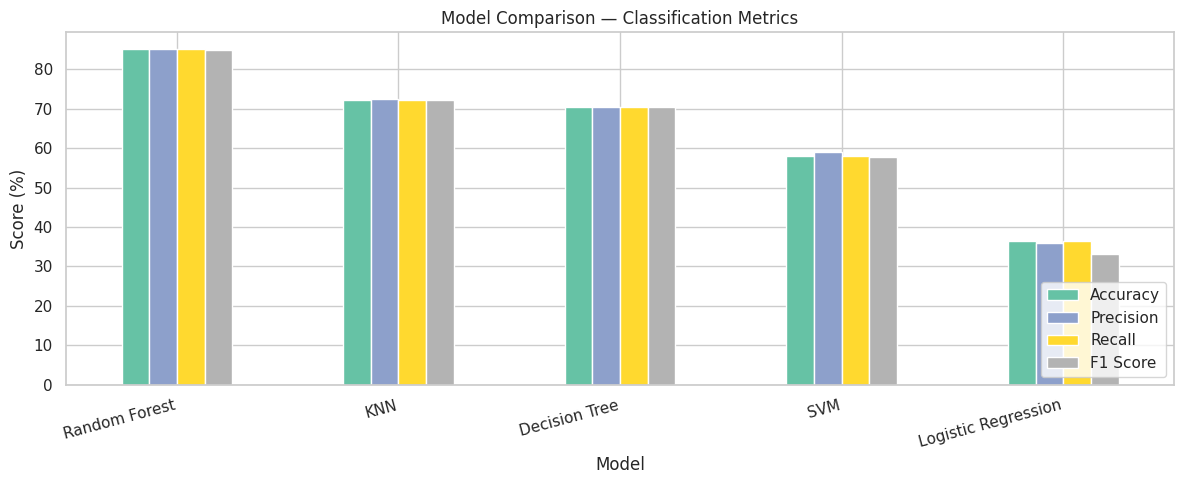

In [36]:
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 5), colormap='Set2'
)
plt.title('Model Comparison — Classification Metrics')
plt.ylabel('Score (%)')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Confusion Matrix

Best model: Random Forest

              precision    recall  f1-score   support

        High       0.85      0.90      0.87       592
         Low       0.86      0.74      0.79       801
      Medium       0.82      0.89      0.86       580
   Very High       0.87      0.94      0.90       471

    accuracy                           0.85      2444
   macro avg       0.85      0.87      0.86      2444
weighted avg       0.85      0.85      0.85      2444



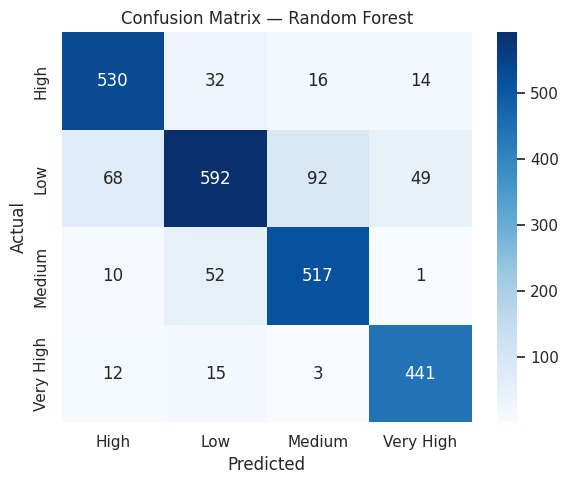

In [37]:
best_name = results_df.iloc[0]['Model']
best_model = trained[best_name]
y_pred_best = best_model.predict(X_test)

print(f'Best model: {best_name}')
print()
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

#Feature Importance

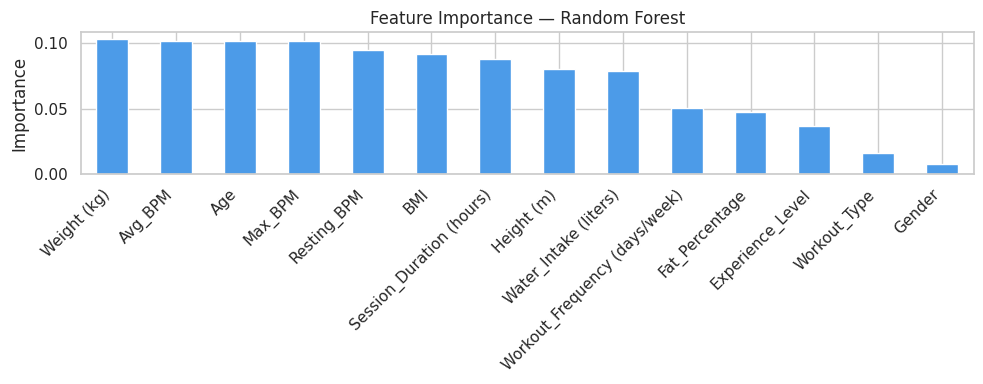

In [38]:
rf_model = trained['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 4), color='#4C9BE8'
)
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()